In [49]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import requests
import warnings
warnings.simplefilter('ignore')

In [42]:
RANDOM_STATE = 42
train_df = pd.read_csv("https://raw.githubusercontent.com/BKHV/ds-test/master/data/PD-data-train.csv", sep = ';')
test_df = pd.read_csv("https://raw.githubusercontent.com/BKHV/ds-test/master/data/PD-data-test.csv", sep = ';')
val = pd.read_csv("https://raw.githubusercontent.com/BKHV/ds-test/master/data/PD-data-desc.csv", sep = ';')
train_df_clean = train_df.dropna(how='all')
test_df_clean = test_df.dropna(how='all')
train_df['default_12m'].values()

TypeError: 'numpy.ndarray' object is not callable

In [48]:
train_df['default_12m'].value_counts()

default_12m
0    30304
1     2091
Name: count, dtype: int64

In [3]:
df = pd.concat([train_df_clean, test_df_clean], sort=False)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
Index: 32595 entries, 0 to 199
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     32595 non-null  int64  
 1   ar_revenue                    17332 non-null  float64
 2   ar_total_expenses             17332 non-null  float64
 3   ar_sale_cost                  17332 non-null  float64
 4   ar_selling_expenses           17332 non-null  float64
 5   ar_management_expenses        17332 non-null  float64
 6   ar_sale_profit                17332 non-null  float64
 7   ar_balance_of_rvns_and_expns  17332 non-null  float64
 8   ar_profit_before_tax          17332 non-null  float64
 9   ar_taxes                      17332 non-null  float64
 10  ar_other_profit_and_losses    17332 non-null  float64
 11  ar_net_profit                 17332 non-null  float64
 12  ab_immobilized_assets         17332 non-null  float64
 13  ab_mobil

,record_id,ar_revenue,ar_total_expenses,ar_sale_cost,ar_selling_expenses,ar_management_expenses,ar_sale_profit,ar_balance_of_rvns_and_expns,ar_profit_before_tax,ar_taxes,...,adr_actual_age,head_actual_age,cap_actual_age,ul_staff_range,ul_capital_sum,ul_founders_cnt,ul_branch_cnt,ul_strategic_flg,ul_systematizing_flg,default_12m
0,7,52996000.0,48344000.0,48344000.0,0.0,0.0,4652000.0,-2608000.0,2044000.0,846000.0,...,3,3,3,[1-100],50000.0,2,0,0,0,0.0
1,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12,12,12,[1-100],10000.0,5,0,0,0,0.0
2,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28,28,28,[1-100],10000.0,2,0,0,0,0.0
3,22,32049000.0,29568000.0,29568000.0,0.0,0.0,2481000.0,-260000.0,2221000.0,302000.0,...,8,8,8,[1-100],300000.0,1,0,0,0,0.0
4,23,16458000.0,14935000.0,14935000.0,0.0,0.0,1523000.0,-274000.0,1249000.0,538000.0,...,27,27,27,[1-100],10000.0,2,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,265577,21287000.0,18838000.0,16227000.0,2611000.0,0.0,2449000.0,-123000.0,2326000.0,483000.0,...,32,32,32,[1-100],10000.0,1,0,0,0,NaN
196,266648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6,6,6,[1-100],0.0,1,0,0,0,NaN
197,266849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7,7,7,[1-100],20000.0,1,0,0,0,NaN
198,267566,759009000.0,726682000.0,551903000.0,18323000.0,156456000.0,32327000.0,-23281000.0,9046000.0,431000.0,...,31,31,31,[1-100],100000.0,2,0,0,0,NaN


In [4]:
staff_dummies = pd.get_dummies(df['ul_staff_range'], prefix='staff')

df = pd.concat([df, staff_dummies], axis=1)

df = df.drop('ul_staff_range', axis=1)


In [5]:

df = df.dropna(subset=['default_12m'])
df = df.dropna()

In [7]:
df.corr()

,record_id,ar_revenue,ar_total_expenses,ar_sale_cost,ar_selling_expenses,ar_management_expenses,ar_sale_profit,ar_balance_of_rvns_and_expns,ar_profit_before_tax,ar_taxes,...,cap_actual_age,ul_capital_sum,ul_founders_cnt,ul_branch_cnt,ul_strategic_flg,ul_systematizing_flg,default_12m,staff_(100-500],staff_> 500,staff_[1-100]
record_id,1.000000,0.008977,0.010026,0.009842,0.004838,0.004135,-0.004447,0.003215,-0.003456,-0.002677,...,0.006918,-0.004294,0.019374,0.005429,0.000569,NaN,-0.000788,0.002635,0.001692,-0.003099
ar_revenue,0.008977,1.000000,0.988667,0.983769,0.467396,0.227638,0.314700,-0.188154,0.256794,0.427735,...,-0.032990,0.112067,0.064752,0.099347,0.051243,NaN,-0.059296,0.391567,0.190183,-0.439763
ar_total_expenses,0.010026,0.988667,1.000000,0.993832,0.475857,0.243276,0.168633,-0.170092,0.116106,0.391232,...,-0.031132,0.108517,0.064668,0.098173,0.051011,NaN,-0.056062,0.386800,0.180564,-0.431936
ar_sale_cost,0.009842,0.983769,0.993832,1.000000,0.394327,0.183877,0.175477,-0.168563,0.123435,0.388756,...,-0.029092,0.103909,0.059817,0.086796,0.054502,NaN,-0.056660,0.388351,0.170951,-0.430168
ar_selling_expenses,0.004838,0.467396,0.475857,0.394327,1.000000,0.059945,0.060102,-0.042593,0.046977,0.125683,...,-0.029064,0.033480,0.065927,0.124590,-0.002390,NaN,-0.020460,0.133307,0.151686,-0.179151
ar_management_expenses,0.004135,0.227638,0.243276,0.183877,0.059945,1.000000,-0.043545,-0.108625,-0.077325,0.191026,...,-0.012443,0.112934,0.026164,0.060401,-0.001819,NaN,-0.009482,0.115740,0.065968,-0.133288
ar_sale_profit,-0.004447,0.314700,0.168633,0.175477,0.060102,-0.043545,1.000000,-0.159930,0.951916,0.334755,...,-0.019765,0.049684,0.016271,0.031572,0.013922,NaN,-0.034862,0.125304,0.107040,-0.156363
ar_balance_of_rvns_and_expns,0.003215,-0.188154,-0.170092,-0.168563,-0.042593,-0.108625,-0.159930,1.000000,0.150175,-0.146045,...,-0.013684,-0.017250,0.050535,-0.018525,-0.021944,NaN,0.005408,0.017520,-0.037635,-0.004053
ar_profit_before_tax,-0.003456,0.256794,0.116106,0.123435,0.046977,-0.077325,0.951916,0.150175,1.000000,0.289948,...,-0.024042,0.044407,0.031980,0.025872,0.007134,NaN,-0.033238,0.130936,0.095526,-0.157863
ar_taxes,-0.002677,0.427735,0.391232,0.388756,0.125683,0.191026,0.334755,-0.146045,0.289948,1.000000,...,-0.023764,0.009097,0.003163,0.045747,0.043825,NaN,-0.043877,0.166656,0.063688,-0.181326


In [8]:
def remove_correlated_smart(df, threshold=0.5, priority_features=None):
    corr_matrix = df.corr().abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    to_drop = set()
    
    for column in upper_triangle.columns:
        correlated = upper_triangle.index[upper_triangle[column] > threshold].tolist()
        
        if correlated:
            all_corr = [column] + correlated
            if priority_features:
                keep = [f for f in all_corr if f in priority_features]
                if keep:
                   
                    keep = keep[0]
                    
                    to_drop.update([f for f in all_corr if f != keep])
                else:
                    
                    to_drop.update(correlated)
            else:
                to_drop.update(correlated)

    df_reduced = df.drop(columns=list(to_drop))
    
    print(f"Было: {len(df.columns)} признаков")
    print(f"Удалено: {len(to_drop)} признаков")
    print(f"Осталось: {len(df_reduced.columns)} признаков")
    print(f"\nУдаленные признаки: {sorted(to_drop)}")
    
    return df_reduced, list(to_drop)
priority = ['ar_revenue', 'ar_net_profit', 'ab_own_capital']
df_cleaned, removed = remove_correlated_smart(df, threshold=0.5, priority_features=priority)

Было: 39 признаков
Удалено: 17 признаков
Осталось: 22 признаков

Удаленные признаки: ['ab_accounts_payable', 'ab_accounts_receivable', 'ab_borrowed_capital', 'ab_cash_and_securities', 'ab_immobilized_assets', 'ab_inventory', 'ab_losses', 'ab_mobile_current_assets', 'adr_actual_age', 'ar_profit_before_tax', 'ar_sale_cost', 'ar_sale_profit', 'ar_taxes', 'ar_total_expenses', 'bus_age', 'head_actual_age', 'staff_(100-500]']


In [9]:
df = df_cleaned
X = df.iloc[:,1:]
del X['default_12m']
y = df['default_12m']

In [10]:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) 

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

In [33]:
model = LogisticRegression()

In [34]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
pred = model.predict(X_test)

In [36]:
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

In [37]:
roc_auc = roc_auc_score(y_test, pred)

pr_auc = average_precision_score(y_test, pred)

In [38]:
roc_auc

0.5

In [39]:
pr_auc

0.04599033816425121

In [18]:
print(df['default_12m'].value_counts())

default_12m
0.0    16454
1.0      796
Name: count, dtype: int64


In [19]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_train, y_train)

In [20]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(f"RF ROC AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

RF ROC AUC: 0.735


In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()


scale_pos_weight = negatives / positives
print(f"Баланс классов в train: {positives} положительных, {negatives} отрицательных")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")
xgb = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.03,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)
xgb_score = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
print(f"XGB ROC AUC: {xgb_score:.3f}")

Баланс классов в train: 558 положительных, 11517 отрицательных
scale_pos_weight = 20.64
XGB ROC AUC: 0.713


In [29]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier([
    ('xgb', XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.03, 
                          scale_pos_weight=14.35, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=250, max_depth=3, 
                                  class_weight='balanced', random_state=42))
], voting='soft')

ensemble.fit(X_train, y_train)
print(f"Ensemble ROC AUC: {roc_auc_score(y_test, ensemble.predict_proba(X_test)[:,1]):.3f}")

Ensemble ROC AUC: 0.710


In [23]:
auc_train = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

In [24]:
auc_train

0.7134495483427319

In [30]:
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.6546238912822572

In [31]:
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(
    boosting_type='gbdt',
    num_leaves=5,      
    max_depth=3,
    learning_rate=0.07,
    n_estimators=200,
    reg_alpha=0.5,
    reg_lambda=1.0,
    subsample=0.7,
    random_state=42
)

model_lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 558, number of negative: 11517
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3389
[LightGBM] [Info] Number of data points in the train set: 12075, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.046211 -> initscore=-3.027221
[LightGBM] [Info] Start training from score -3.027221


,boosting_type,'gbdt'
,num_leaves,5
,max_depth,3
,learning_rate,0.07
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [32]:
roc_auc_score(y_test, model_lgb.predict_proba(X_test)[:, 1])

0.7159844290156817

In [40]:
pr_auc = average_precision_score(y_test, rf.predict_proba(X_test)[:,1])

In [41]:
pr_auc

0.24658986696848614

In [52]:
from sklearn.metrics import recall_score

recall_score(y_test, rf.predict(X_test))

0.10504201680672269

In [53]:
probs = rf.predict_proba(X_test)[:, 1]

In [84]:
y_pred_custom = (probs > 0.03).astype(int)

recall_score(y_test, y_pred_custom)

0.7815126050420168

In [85]:
roc_auc_score(y_test, y_pred_custom)

0.6699744511942918

In [89]:
import numpy as np

for t in np.arange(0.01, 1.0, 0.05):
    y_pred = (probs > t).astype(int)

    rec = recall_score(y_test, y_pred)
    per = precision_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    

    print(f"threshold={t:.2f} recall={rec:.3f} per={per:.3f} f1={f1:.3f}")

threshold=0.01 recall=0.882 per=0.061 f1=0.114
threshold=0.06 recall=0.563 per=0.096 f1=0.164
threshold=0.11 recall=0.345 per=0.153 f1=0.212
threshold=0.16 recall=0.252 per=0.246 f1=0.249
threshold=0.21 recall=0.206 per=0.402 f1=0.272
threshold=0.26 recall=0.172 per=0.526 f1=0.259
threshold=0.31 recall=0.168 per=0.635 f1=0.266
threshold=0.36 recall=0.160 per=0.704 f1=0.260
threshold=0.41 recall=0.147 per=0.778 f1=0.247
threshold=0.46 recall=0.113 per=0.771 f1=0.198
threshold=0.51 recall=0.097 per=0.793 f1=0.172
threshold=0.56 recall=0.080 per=0.826 f1=0.146
threshold=0.61 recall=0.063 per=0.789 f1=0.117
threshold=0.66 recall=0.050 per=0.857 f1=0.095
threshold=0.71 recall=0.034 per=0.889 f1=0.065
threshold=0.76 recall=0.021 per=1.000 f1=0.041
threshold=0.81 recall=0.017 per=1.000 f1=0.033
threshold=0.86 recall=0.004 per=1.000 f1=0.008
threshold=0.91 recall=0.000 per=0.000 f1=0.000
threshold=0.96 recall=0.000 per=0.000 f1=0.000


In [88]:
from sklearn.metrics import recall_score, precision_score, f1_score

In [90]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)

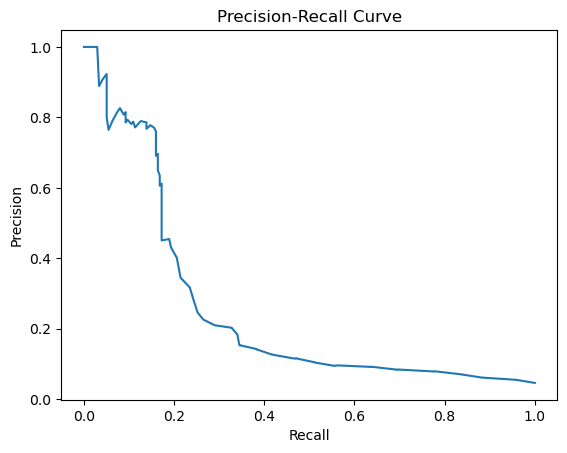

In [92]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.savefig("pr_curve.png", dpi=300, bbox_inches='tight')
plt.show()